In [115]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from IPython.display import IFrame

In [98]:
pip install pdoc

In [108]:
code = """ 
#Le script commence par l’importation de plusieurs bibliothèques Python essentielles 
#pour le traitement et la modélisation de données. Pandas et NumPy permettent de manipuler efficacement les 
#tableaux de données et d’effectuer des calculs numériques. Les modules de scikit-learn sont utilisés pour 
#le prétraitement, la sélection de caractéristiques, la création de modèles d’apprentissage automatique et 
#l’évaluation des performances. Plus précisément, OneHotEncoder, MinMaxScaler et FunctionTransformer servent 
#à transformer et normaliser les données, tandis que Pipeline et ColumnTransformer permettent d’automatiser tout 
#le processus d’analyse. Enfin, matplotlib est importé pour visualiser les résultats, notamment les caractéristiques les plus importantes.

#Le code lit ensuite deux fichiers CSV contenant les données : bank-full.csv et bank.csv. Le premier représente le jeu d’entraînement,
#c’est-à-dire celui sur lequel le modèle apprendra à reconnaître les comportements des clients. Le second constitue le jeu de test,
#qui servira plus tard à évaluer la performance du modèle. L’instruction pd.read_csv() charge ces fichiers dans deux DataFrames
#Pandas appelés donnee_train et donnee_test, en précisant que les valeurs sont séparées par des points-virgules (sep=';').
#Un aperçu des premières lignes du jeu d’entraînement est ensuite affiché avec head() afin de vérifier la structure des données 
#et le contenu des colonnes.

#Le script définit ensuite une petite fonction appelée donnee_propre(df). Celle-ci a pour but de nettoyer automatiquement 
#les données avant leur utilisation. Dans ce cas, elle remplace toutes les valeurs "unknown" (inconnues) par la chaîne "missing", 
#plus explicite et plus facile à traiter lors de l’encodage. La fonction fait une copie du DataFrame avant toute modification,
#pour ne pas altérer les données d’origine. Cette fonction est ensuite transformée en un objet scikit-learn grâce à FunctionTransformer, 
#ce qui permet de l’intégrer facilement à un pipeline d’apprentissage automatique. Ainsi, le nettoyage pourra s’exécuter automatiquement 
#sur tout nouveau jeu de données, sans intervention manuelle.

#Les étapes suivantes préparent les données pour l’entraînement. La colonne y, qui indique si le client a souscrit ou non à un dépôt à terme,
#est considérée comme la variable cible à prédire. On l’encode avec LabelEncoder afin de la convertir en valeurs numériques (par exemple,
#0 pour "no" et 1 pour "yes"). Ensuite, la colonne y est supprimée du reste du tableau pour former X_train et X_test, 
#les jeux de données contenant uniquement les variables explicatives (âge, métier, situation matrimoniale, solde, etc.).

#Le code détecte ensuite le type de chaque variable pour appliquer des transformations adaptées. Les colonnes contenant du texte (object)
#sont considérées comme catégorielles, tandis que les autres sont numériques. Cette distinction est importante : les données catégorielles doivent être converties
#en nombres avant d’être utilisées dans un modèle, tandis que les données numériques doivent être normalisées afin que leurs valeurs soient comparables.

#Le bloc suivant crée un préprocesseur automatique à l’aide de ColumnTransformer. Cet objet applique deux traitements différents selon le type de colonne:
#un MinMaxScaler sur les colonnes numériques pour ramener leurs valeurs entre 0 et 1, et un OneHotEncoder sur les colonnes catégorielles pour les transformer 
#en variables binaires (par exemple, "job = admin" devient une colonne prenant 1 ou 0). Grâce à l’option handle_unknown='ignore', 
#l’encodeur ignore les catégories inconnues dans le jeu de test, ce qui évite les erreurs.

#Une fois le nettoyage et le prétraitement définis, le script construit un pipeline complet regroupant toutes les étapes du traitement de bout en bout.
#Ce pipeline comprend quatre parties principales :

#Le nettoyage des données (cleaning),

#Le prétraitement (preprocessing),

#La sélection des caractéristiques (SelectKBest avec la méthode du chi-deux pour choisir les 15 variables les plus pertinentes),

#Et la modélisation avec un RandomForestClassifier, un algorithme d’ensemble basé sur plusieurs arbres de décision.

#Le pipeline est alors prêt à être entraîné. Avec la commande pipeline.fit(X_train, y_train), toutes les étapes sont exécutées dans le bon ordre :
#nettoyage → transformation → sélection → apprentissage. Cela garantit que le modèle est entraîné de manière cohérente, 
#sans fuite de données ni traitement manuel.

#Une fois entraîné, le pipeline est utilisé pour faire des prédictions automatiques sur le jeu de test (y_pred = pipeline.predict(X_test)).
#Cela permet d’évaluer la capacité du modèle à généraliser ses connaissances sur des données qu’il n’a jamais vues.

#Ensuite, le script analyse les caractéristiques les plus importantes utilisées par le modèle. Pour cela, 
#il récupère d’abord tous les noms de variables créés après le prétraitement, puis ne garde que ceux sélectionnés par SelectKBest. 
#Le modèle Random Forest attribue une importance à chaque variable selon son influence sur la prédiction. 
#Ces importances sont regroupées dans une série Pandas (pd.Series) et affichées dans un graphique à barres horizontales, 
#montrant les 15 variables ayant le plus d’impact sur la décision du modèle.

#Enfin, le code évalue la qualité du modèle à l’aide de plusieurs indicateurs. 
#La précision globale (accuracy) mesure la proportion de bonnes prédictions. 
#La matrice de confusion montre combien de cas “yes” et “no” ont été correctement ou incorrectement classés.
#Le rapport de classification donne des informations plus détaillées, notamment la précision, le rappel et le score F1 pour chaque classe, 
#ce qui permet de juger la performance du modèle de manière complète.

#En résumé, ce code met en place un pipeline d’apprentissage supervisé complet et automatique pour le dataset Bank Marketing.
#Il nettoie les données, les prépare, sélectionne les variables les plus utiles, entraîne un modèle robuste et 
#évalue ses performances sur un jeu de test indépendant. L’avantage principal de cette approche est qu’elle rend tout le processus reproductible,
#cohérent et automatisé, sans nécessiter d’interventions manuelles à chaque nouvelle exécution.
"""

# Étape 2 : Écriture du fichier Python
with open("nettoyage_donnees_UA2.py", "w", encoding="utf-8") as f:
    f.write(code)

print("✅ Le fichier 'nettoyage_donnees_UA2.py' a été créé avec succès.")

✅ Le fichier 'nettoyage_donnees_UA2.py' a été créé avec succès.


In [112]:
!pdoc --output-dir docs nettoyage_donnees_UA2.py

In [111]:
IFrame(src="./docs/nettoyage_donnees_UA2.html", width=900, height=600)

In [76]:
donnee_train = pd.read_csv("C:/Users/ADMIN/Desktop/bank-full.csv", sep=';')
donnee_test = pd.read_csv("C:/Users/ADMIN/Desktop/bank.csv", sep=';')


In [77]:
print("<< Aperçu du jeu d'entraînement >>")
print(donnee_train.head())

<< Aperçu du jeu d'entraînement >>
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [78]:
def donnee_propre(df):
    df = df.copy()
    df.replace("unknown", "missing", inplace=True)
    return df


In [113]:
def gerer_valeurs_aberrantes(df, colonnes_numeriques, methode='IQR'):
    """
    Détecte et gère les valeurs aberrantes dans les colonnes numériques.

    Args:
        df (DataFrame): Jeu de données initial.
        colonnes_numeriques (list): Liste des colonnes à traiter.
        methode (str): Méthode utilisée pour détecter les outliers ('IQR' ou 'Z-score').

    Returns:
        DataFrame: Jeu de données avec valeurs aberrantes corrigées.
    """

    df = df.copy()

    if methode == 'IQR':
        for col in colonnes_numeriques:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            borne_inf = Q1 - 1.5 * IQR
            borne_sup = Q3 + 1.5 * IQR

            # Remplace les valeurs aberrantes par les bornes
            df[col] = df[col].clip(lower=borne_inf, upper=borne_sup)

    elif methode == 'Z-score':
        from scipy import stats
        for col in colonnes_numeriques:
            z_scores = (df[col] - df[col].mean()) / df[col].std()
            df.loc[z_scores.abs() > 3, col] = df[col].median()

    else:
        raise ValueError("Méthode non reconnue : utilisez 'IQR' ou 'Z-score'.")

    return df


In [117]:
gerer_valeurs_aberrantes= FunctionTransformer(donnee_propre)

In [79]:
# ici nous allons transformer notre fonction de base python en objet reutisable dans les pipelines cpour qu'il puisse savoir c'est quoi fit()...
cleaner = FunctionTransformer(donnee_propre)


In [80]:
# sur la premiere ligne nous allons d'abord transformer les cathegorie en numerique avec label encoder et sur la deuxieme ligne supprrimer la colonne y,
#c'est a dire la cible pour permetre de predire sans la cible
y_train = LabelEncoder().fit_transform(donnee_train['y'])
X_train = donnee_train.drop('y', axis=1)

In [81]:
# sur la premiere ligne nous allons d'abord transformer les cathegorie en numerique avec label encoder et sur la deuxieme ligne supprrimer la colonne y,
#c'est a dire la cible pour permetre de predire sans la cible
y_test = LabelEncoder().fit_transform(donnee_test['y'])
X_test = donnee_test.drop('y', axis=1)

In [82]:
# ici nous allons detecter les types de chaque variable pour adapter chaque transformation en fonction du type
cat_cols = X_train.select_dtypes(include=['object']).columns
num_cols = X_train.select_dtypes(exclude=['object']).columns

In [83]:
print("\nVariables catégorielles :", list(cat_cols))
print("Variables numériques :", list(num_cols))


Variables catégorielles : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Variables numériques : ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [84]:
# Ici nous allons normaliser les valeurs numeriques et encoder les variables cathegorielles
preprocessor = ColumnTransformer([
    ('num', MinMaxScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [118]:
# Nous allons maintenant proceder a la creation d'un pipeline complet reutilisable
pipeline = Pipeline(steps=[
    ('cleaning', cleaner),
    ('outliers',gerer_valeurs_aberrantes),
    ('preprocessing', preprocessor),  
    ('feature_selection', SelectKBest(score_func=chi2, k=15)), 
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [92]:
model = pipeline.named_steps['model']
importances = model.feature_importances_

num__duration            0.752076
cat__poutcome_success    0.082866
cat__poutcome_missing    0.025064
cat__month_mar           0.018618
cat__month_oct           0.015563
cat__contact_missing     0.013815
cat__housing_no          0.012986
cat__month_sep           0.012586
cat__contact_cellular    0.012522
cat__housing_yes         0.011780
cat__month_may           0.010930
cat__job_retired         0.008602
cat__job_blue-collar     0.008426
cat__job_student         0.008264
cat__month_dec           0.005901
dtype: float64


<Axes: title={'center': 'Top 15 des caractéristiques les plus importantes'}>

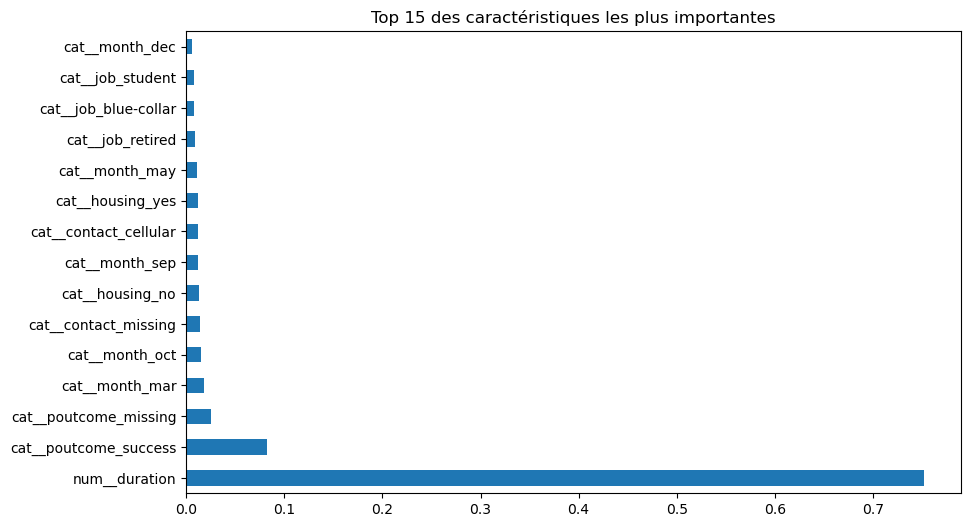

In [94]:
# 1. Récupérer les noms complets avant sélection
all_feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()

# 2. Récupérer le masque des 15 colonnes sélectionnées
mask = pipeline.named_steps['feature_selection'].get_support()

# 3. Filtrer les 15 noms sélectionnés
selected_feature_names = all_feature_names[mask]

# 4. Créer la série avec les importances correspondantes
importances = pipeline.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=selected_feature_names).sort_values(ascending=False)

# 5. Afficher ou tracer
print(feat_imp.head(15))
feat_imp.head(15).plot(kind='barh', figsize=(10,6), title="Top 15 des caractéristiques les plus importantes")


In [119]:
print("\n Entraînement du pipeline sur bank-full.csv ...")
pipeline.fit(X_train, y_train)


 Entraînement du pipeline sur bank-full.csv ...


Pipeline(steps=[('cleaning',
                 FunctionTransformer(func=<function donnee_propre at 0x000002BA3E85EA20>)),
                ('outliers',
                 FunctionTransformer(func=<function donnee_propre at 0x000002BA3E85EA20>)),
                ('preprocessing',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('feature_selection',
                 SelectKBest(k=15,
                             score_func=<function chi2 at 0x000002BA3D415260>)),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [89]:
print("\n Prédiction automatique sur bank.csv ...")
y_pred = pipeline.predict(X_test)


 Prédiction automatique sur bank.csv ...


In [120]:
print("\n Accuracy globale :", round(accuracy_score(y_test, y_pred), 3))
print("\n<< Matrice de confusion >>")
print(confusion_matrix(y_test, y_pred))
print("\n<< Rapport de classification >>")
print(classification_report(y_test, y_pred))


 Accuracy globale : 0.963

<< Matrice de confusion >>
[[3968   32]
 [ 136  385]]

<< Rapport de classification >>
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      4000
           1       0.92      0.74      0.82       521

    accuracy                           0.96      4521
   macro avg       0.95      0.87      0.90      4521
weighted avg       0.96      0.96      0.96      4521



In [1]:
import os
print(os.getcwd())

C:\Users\ADMIN\Intelligene artificielle devoir
